<a href="https://colab.research.google.com/github/enjomcoding/Earthquake_Decision-Tree/blob/main/Tijada_Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Decision Tree Modeling for Post-Earthquake Structural Damage**
This project utilizes a decision tree classifier to assess seismic vulnerability in buildings. By analyzing a comprehensive set of 38 tabular features, ranging from geographic location IDs and physical dimensions (such as age, area, and number of floors) to specific construction materials (like foundation type, roof type, and mud-mortar stone superstructures), the model predicts the specific damage grade a structure is likely to sustain during an earthquake. This provides a clear, data-driven approach to evaluating post-earthquake structural health and risk.

# **1. Preparing the Environment**

**1.1 Install Pycaret**

In [ ]:
!pip install git+https://github.com/pycaret/pycaret.git@master --upgrade

  Cloning https://github.com/pycaret/pycaret.git (to revision master) to /tmp/pip-req-build-5_23ahwe
  Running command git clone --filter=blob:none --quiet https://github.com/pycaret/pycaret.git /tmp/pip-req-build-5_23ahwe
  Resolved https://github.com/pycaret/pycaret.git to commit 58ec3c282d58e94727f9d5b77b49f241e9103ab3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


**1.2 Import required libraries and modules**

In [ ]:
import sys
import pandas as pd
import pycaret
from pycaret.classification import *
import pycaret.utils.generic
import pycaret.internal.metrics

**1.3 Load dataset**

In [ ]:
# Load the datasets
features = pd.read_csv('train_values.csv')
labels = pd.read_csv('train_labels.csv')

# Merge into a single dataframe
seis_data = pd.merge(features, labels, on='building_id')

**1.5 Display first five observations**

In [ ]:
seis_data.head()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
0,802906,6,487,12198,2,30,6,5,t,r,...,0,0,0,0,0,0,0,0,0,3
1,28830,8,900,2812,2,10,8,7,o,r,...,0,0,0,0,0,0,0,0,0,2
2,94947,21,363,8973,2,10,5,5,t,r,...,0,0,0,0,0,0,0,0,0,3
3,590882,22,418,10694,2,10,6,5,t,r,...,0,0,0,0,0,0,0,0,0,2
4,201944,11,131,1488,3,30,8,9,t,r,...,0,0,0,0,0,0,0,0,0,3


# **2. Understanding the Data**

**2.1 Display the number of observations, column names, and data types**

In [ ]:
seis_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260601 entries, 0 to 260600
Data columns (total 40 columns):
 #   Column                                  Non-Null Count   Dtype 
---  ------                                  --------------   ----- 
 0   building_id                             260601 non-null  int64 
 1   geo_level_1_id                          260601 non-null  int64 
 2   geo_level_2_id                          260601 non-null  int64 
 3   geo_level_3_id                          260601 non-null  int64 
 4   count_floors_pre_eq                     260601 non-null  int64 
 5   age                                     260601 non-null  int64 
 6   area_percentage                         260601 non-null  int64 
 7   height_percentage                       260601 non-null  int64 
 8   land_surface_condition                  260601 non-null  object
 9   foundation_type                         260601 non-null  object
 10  roof_type                               260601 non-null 

**2.2 Display the summary statistics**

In [ ]:
seis_data.describe()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
count,2.606010e+05,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,...,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000
mean,5.256755e+05,13.900353,701.074685,6257.876148,2.129723,26.535029,8.018051,5.434365,0.088645,0.761935,...,0.033626,0.008101,0.000940,0.000361,0.001071,0.000188,0.000146,0.000088,0.005119,2.238272
std,3.045450e+05,8.033617,412.710734,3646.369645,0.727665,73.565937,4.392231,1.918418,0.284231,0.425900,...,0.180265,0.089638,0.030647,0.018989,0.032703,0.013711,0.012075,0.009394,0.071364,0.611814
min,4.000000e+00,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.611900e+05,7.000000,350.000000,3073.000000,2.000000,10.000000,5.000000,4.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,5.257570e+05,12.000000,702.000000,6270.000000,2.000000,15.000000,7.000000,5.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,7.897620e+05,21.000000,1050.000000,9412.000000,2.000000,30.000000,9.000000,6.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,1.052934e+06,30.000000,1427.000000,12567.000000,9.000000,995.000000,100.000000,32.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000


In [ ]:
seis_data.describe(exclude='number')

,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,legal_ownership_status
count,260601,260601,260601,260601,260601,260601,260601,260601
unique,3,5,3,5,4,4,10,4
top,t,r,n,f,q,s,d,v
freq,216757,219196,182842,209619,165282,202090,250072,250939


**2.3 Display the distribution plots of the variables**

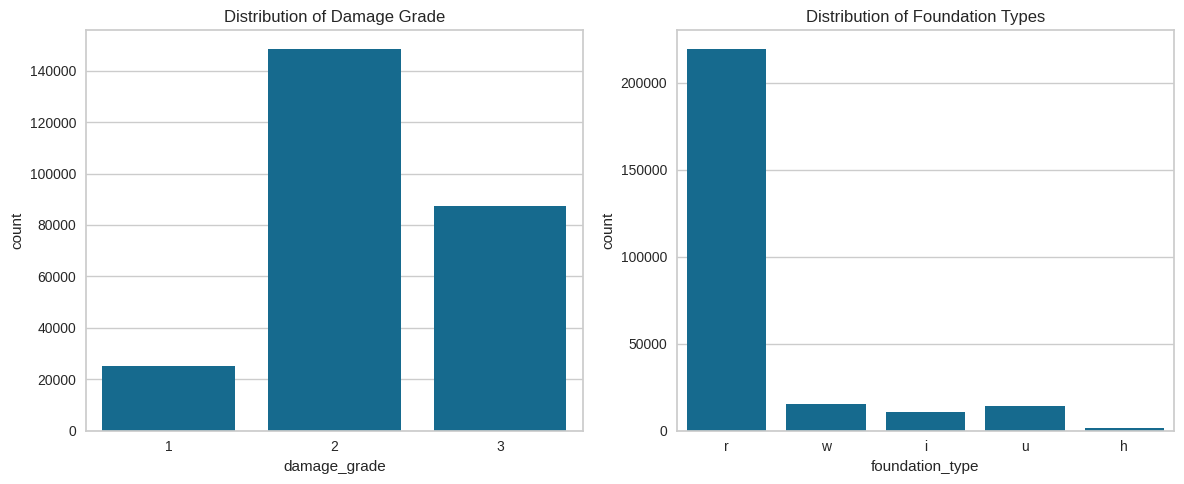

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# Plot for the target variable
plt.subplot(1, 2, 1)
sns.countplot(data=seis_data, x='damage_grade')
plt.title('Distribution of Damage Grade')

# Plot for a feature
plt.subplot(1, 2, 2)
sns.countplot(data=seis_data, x='foundation_type')
plt.title('Distribution of Foundation Types')

plt.tight_layout()
plt.show()

# **3. Data preprocessing**

**3.1 Remove Outliers**

**3.2 Apply normalization**

**3.3 Impute missing values**

**3.4 Apply transformation**

**3.5 Split the dataset into train and test data using 80:20 ratio**

In [ ]:
pycaret.utils = sys.modules['pycaret.utils']
pycaret.internal = sys.modules['pycaret.internal']

clf_setup = setup(data = seis_data,
                  target = 'damage_grade',
                  train_size = 0.8,
                  session_id = 7402,
                  remove_outliers = True,
                  normalize = True,
                  normalize_method = 'minmax',
                  numeric_imputation = 'mean',
                  categorical_imputation = 'mode',
                  transformation = True)

,Description,Value
0,Session id,7402
1,Target,damage_grade
2,Target type,Multiclass
3,Target mapping,"1: 0, 2: 1, 3: 2"
4,Original data shape,"(260601, 40)"
5,Transformed data shape,"(250177, 70)"
6,Transformed train set shape,"(198056, 70)"
7,Transformed test set shape,"(52121, 70)"
8,Numeric features,31
9,Categorical features,8


**3.5 Display the preprocessed data**

In [ ]:
get_config('dataset_transformed').head()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition_t,land_surface_condition_n,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
231110,0.420183,0.588460,0.107774,0.944869,0.000000,0.240311,0.310716,0.000000,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
195209,0.707271,0.915398,0.074782,0.877959,0.248064,0.171354,0.630875,0.374114,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
45988,0.785280,0.937068,0.506537,0.643702,0.000000,0.495394,0.365989,0.086834,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
129839,0.137054,0.494402,0.985044,0.223465,0.248064,0.349338,0.411163,0.159319,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
150191,0.703837,0.915398,0.427515,0.995236,0.248064,0.240311,0.365989,0.222100,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


# **4. Modelling**

**4.1 Compare different classification models**

In [ ]:
classification = compare_models(sort='Accuracy')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
xgboost,Extreme Gradient Boosting,0.7223,0.8179,0.7223,0.7225,0.7140,0.4692,0.4782,28.1730
rf,Random Forest Classifier,0.7122,0.8066,0.7122,0.7110,0.7039,0.4509,0.4591,78.8680
lightgbm,Light Gradient Boosting Machine,0.7120,0.8055,0.7120,0.7130,0.7017,0.4450,0.4564,36.1540
et,Extra Trees Classifier,0.6934,0.7851,0.6934,0.6897,0.6865,0.4210,0.4261,85.3910
gbc,Gradient Boosting Classifier,0.6818,0.0000,0.6818,0.6844,0.6657,0.3759,0.3934,182.8260
ada,Ada Boost Classifier,0.6430,0.0000,0.6430,0.6565,0.6087,0.2745,0.3104,32.4560
dt,Decision Tree Classifier,0.6416,0.6725,0.6416,0.6426,0.6420,0.3567,0.3568,21.4480
knn,K Neighbors Classifier,0.6276,0.7027,0.6276,0.6215,0.6225,0.3081,0.3098,74.9770
lr,Logistic Regression,0.5957,0.0000,0.5957,0.5847,0.5492,0.1675,0.1949,26.9230
ridge,Ridge Classifier,0.5931,0.0000,0.5931,0.5846,0.5351,0.1438,0.1773,18.3110


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

**4.2 Create a Decision Tree model**

In [ ]:
DT = create_model('dt')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6397,0.6715,0.6397,0.6411,0.6403,0.3544,0.3545
1,0.6437,0.6747,0.6437,0.6445,0.6440,0.3603,0.3604
2,0.6418,0.6725,0.6418,0.6426,0.6422,0.3568,0.3568
3,0.6405,0.6716,0.6405,0.6416,0.6410,0.3552,0.3553
4,0.6355,0.6670,0.6355,0.6366,0.6360,0.3462,0.3462
5,0.6428,0.6719,0.6428,0.6428,0.6428,0.3566,0.3566
6,0.6427,0.6736,0.6427,0.6438,0.6432,0.3591,0.3592
7,0.6429,0.6740,0.6429,0.6439,0.6434,0.3592,0.3592
8,0.6430,0.6746,0.6430,0.6445,0.6437,0.3603,0.3603


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

# **5.0 Evaluate the model**

**5.1 Make predictions using the Decision Tree model**

In [ ]:
dt_predictions = predict_model(DT)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Decision Tree Classifier,0.6443,0.6742,0.6443,0.6448,0.6445,0.3606,0.3606


**5.2 Display prediction scores**

In [ ]:
dt_predictions.head()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade,prediction_label,prediction_score
199146,206848,27,422,11125,2,40,5,7,t,w,...,0,0,0,0,0,0,0,3,3,1.0
212763,751787,27,1106,4316,3,45,6,7,t,r,...,0,0,0,0,0,0,0,3,3,1.0
148026,895964,10,735,9632,5,5,10,16,o,i,...,0,0,0,0,0,0,0,2,1,1.0
66592,740888,6,1269,9642,3,50,9,7,n,r,...,0,0,0,0,0,0,0,2,2,1.0
193266,778880,11,883,8864,3,100,4,9,t,r,...,0,0,0,0,0,0,0,3,2,1.0


**5.3 Plot the confusion matrix**

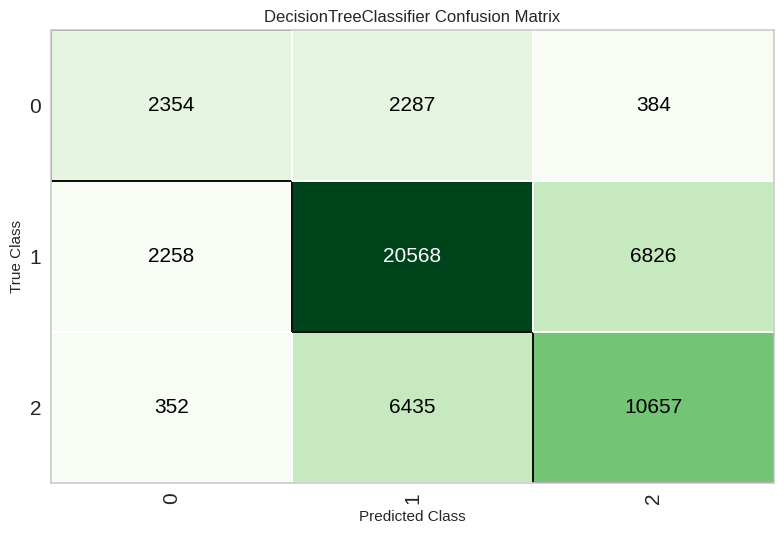

In [ ]:
plot_model(DT, plot = 'confusion_matrix')

**5.4 Plot the model**

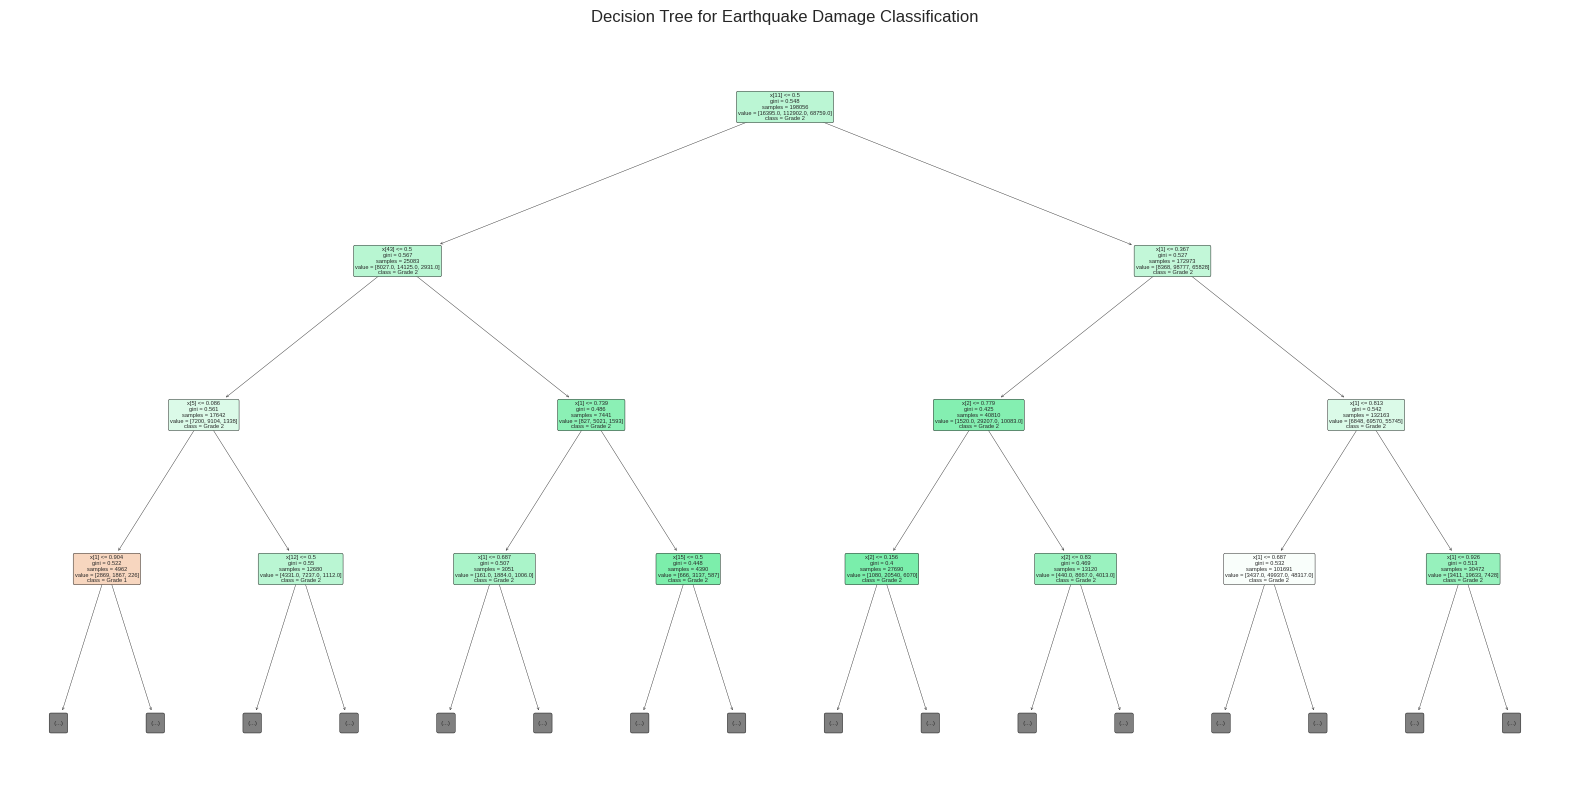

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

plot_tree(DT,
          filled=True,
          rounded=True,
          class_names=['Grade 1', 'Grade 2', 'Grade 3'],
          max_depth=3)

plt.title("Decision Tree for Earthquake Damage Classification")
plt.show()

**5.5 Finalize and save the model**

In [ ]:
final_model = finalize_model(DT)
save_model(final_model, 'earthquake_dt_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['building_id', 'geo_level_1_id',
                                              'geo_level_2_id', 'geo_level_3_id',
                                              'count_floors_pre_eq', 'age',
                                              'area_percentage',
                                              'height_percentage',
                                              'has_supe...
                                     transformer=MinMaxScaler(clip=False,
                                                              copy=True,
                                                              feature_range=(0,
                         

# **Sample Decision**

In [ ]:
sample_building = features.iloc[[0]]

print("Here is the building's raw data:")
display(sample_building)

prediction = predict_model(DT, data=sample_building)

print("\nHere is the model's prediction:")
display(prediction)

print("Building Analysis Results:")
print(f"Assigned Damage Grade: {prediction['prediction_label'].values[0]}")
print(f"Model Confidence: {prediction['prediction_score'].values[0] * 100:.2f}%")

# Simple logic to print the status
grade = prediction['prediction_label'].values[0]
if grade == 1:
    print("Status: Safe / Low Risk")
elif grade == 2:
    print("Status: Restricted Access / Medium Risk")
else:
    print("Status: Unsafe / High Risk")

Here is the building's raw data:


,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
0,802906,6,487,12198,2,30,6,5,t,r,...,0,0,0,0,0,0,0,0,0,0



Here is the model's prediction:


,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,prediction_label,prediction_score
0,802906,6,487,12198,2,30,6,5,t,r,...,0,0,0,0,0,0,0,0,3,1.0


Building Analysis Results:
Assigned Damage Grade: 3
Model Confidence: 100.00%
Status: Unsafe / High Risk
